# 33 — Intra-Patch Reading Direction Census

**Rank-type tag: `typed_gapfill`. Regime: `[LAB]`.**

Every existing "regression" in this project is **vertical**: scroll regressions
(NB07a-c, viewport y-offset), rank-order gaze regressions (NB22 `gaze_regression_label`,
`fix['y']` returning to earlier result positions), and landing precision of return
saccades (NB12). This notebook opens the orthogonal axis: **within-AOI horizontal
saccade direction** — the reading-science regression (leftward saccade inside a
text element), absent from the framework and from the upstream corpus paper
(Latifzadeh, Gwizdka & Leiva, SIGIR 2025, which reports fixation count/duration/
position only).

**Terminology (project convention going forward):**
- *Inter-patch regression* — y-axis, between-AOI, rank-order backtracking (NB22).
  Foraging interpretation: rational re-sampling after downstream evidence.
- *Intra-patch regression* — x-axis, within-AOI, leftward saccade during text
  consumption. Reading interpretation: comprehension repair / evidence re-sampling
  at word grain (Bicknell & Levy 2010).

Conceptual lineage: Gwizdka's reading-vs-scanning classification from saccade
patterns (document grain) — this notebook moves that grain to per-typed-AOI on
a public SERP corpus.

**Coordinate note:** fixations (`fixation-coords/*.json`) and typed-gapfill AOIs
are both PAGE-space (see `data_loader.py` header). No scroll arithmetic anywhere
in this notebook.


### Key Measures

| Measure | Definition | Units |
|---|---|---|
| Within-AOI saccade | Vector between temporally adjacent fixations (gap ≤ MAX_GAP_MS) assigned to the same AOI instance | px |
| Horizontal-dominant | \|dx\| ≥ \|dy\| | bool |
| Intra-patch regression | Horizontal-dominant, dx ≤ −THETA, not a return-sweep candidate | event |
| Return-sweep candidate | dx ≤ −0.5 × AOI width and dy > 0 (line-wrap sweep, counted separately) | event |
| Leftward fraction | regressions / (regressions + forward), per AOI type | ratio |
| First-pass vs re-entry | Visit 1 to an AOI instance vs later visits (re-entries) | — |

### Gates (from exploration plan)

- **Gate A** — text-heavy AOI types (organic, PAA) must show more horizontal-dominant,
  reading-like saccade signatures than visual types (carousel cells, right rail).
  If the contrast is absent, the measure is dead at this tracker precision.
- **Gate B** — for organic AOIs, intra-patch regression count per visit should scale
  with `snippet_chars` (content-features join). No scaling → we're measuring noise.

**Precision honesty:** Gazepoint GP3 HD ≈ 0.5–1° ≈ 20–40 px at this setup; SERP
line-height ≈ 20 px. **Line assignment is not achievable.** We classify direction
statistics only, never line membership. THETA default 40 px with 20/60 sensitivity.


In [1]:
import json, glob, os, math, statistics
from pathlib import Path
from collections import defaultdict

import numpy as np
import matplotlib.pyplot as plt

ROOT = Path('..').resolve()
FIX_DIR = ROOT / 'AdSERP' / 'data' / 'fixation-coords'
AOI_DIR = ROOT / 'data' / 'aoi-typed-gapfill'
CONTENT = ROOT / 'AdSERP' / 'data' / 'content-features-by-position.json'

THETA = 40          # px noise floor for a horizontal saccade component (~1 deg)
MAX_GAP_MS = 1000   # max inter-fixation gap to count the pair as one saccade
SWEEP_FRAC = 0.5    # dx <= -SWEEP_FRAC * aoi_width and dy > 0 -> return-sweep candidate

fix_trials = {p.stem for p in FIX_DIR.glob('*.json')}
aoi_trials = {p.stem for p in AOI_DIR.glob('*.json')}
trials = sorted(fix_trials & aoi_trials)
print(f'fixation trials: {len(fix_trials)}  aoi trials: {len(aoi_trials)}  intersection: {len(trials)}')


fixation trials: 2776  aoi trials: 2776  intersection: 2776


In [2]:
N_NULL_GEOM = 0   # AOIs skipped for null geometry (HTML-typed, no CV bbox)

def load_aois(tid):
    global N_NULL_GEOM
    aois = []
    for i, a in enumerate(json.load(open(AOI_DIR / f'{tid}.json'))):
        if any(a.get(k) is None for k in ('x', 'y', 'width', 'height')):
            N_NULL_GEOM += 1
            continue
        a['idx'] = i
        aois.append(a)
    return aois

def assign(x, y, aois):
    """Point-in-bbox; smallest-area winner if bboxes overlap."""
    best, best_area = None, None
    for a in aois:
        if a['x'] <= x <= a['x'] + a['width'] and a['y'] <= y <= a['y'] + a['height']:
            area = a['width'] * a['height']
            if best is None or area < best_area:
                best, best_area = a, area
    return best

def trial_records(tid, theta=THETA):
    """Yield per-(trial, aoi-instance) saccade census records."""
    fixes = json.load(open(FIX_DIR / f'{tid}.json'))
    aois = load_aois(tid)
    seq = []                       # (fix, aoi or None)
    for f in fixes:
        seq.append((f, assign(f['x'], f['y'], aois)))

    # visit segmentation: run of consecutive fixations on the same AOI instance
    visit_no = defaultdict(int)    # aoi idx -> visits seen so far
    per_aoi = defaultdict(lambda: {
        'n_pairs': 0, 'n_horiz': 0, 'n_fwd': 0, 'n_reg': 0, 'n_sweep': 0,
        'reg_amp': [], 'fwd_amp': [],
        'fp_fwd': 0, 'fp_reg': 0, 're_fwd': 0, 're_reg': 0,
        'n_visits': 0, 'type': None, 'pos': None})

    prev_aoi_idx = None
    cur_visit = {}                 # aoi idx -> current visit number for open run
    for i, (f, a) in enumerate(seq):
        ai = a['idx'] if a else None
        if ai is not None and ai != prev_aoi_idx:
            visit_no[ai] += 1
            cur_visit[ai] = visit_no[ai]
            r = per_aoi[ai]
            r['n_visits'] = visit_no[ai]
            r['type'] = a['type']
            r['pos'] = a.get('position')
        if i == 0:
            prev_aoi_idx = ai
            continue
        pf, pa = seq[i - 1]
        pai = pa['idx'] if pa else None
        if ai is not None and ai == pai:
            gap = f['t'] - (pf['t'] + pf['d'])
            if gap <= MAX_GAP_MS:
                dx = f['x'] - pf['x']
                dy = f['y'] - pf['y']
                r = per_aoi[ai]
                r['n_pairs'] += 1
                if abs(dx) >= abs(dy):
                    r['n_horiz'] += 1
                    is_sweep = (dx <= -SWEEP_FRAC * a['width']) and (dy > 0)
                    first_pass = cur_visit.get(ai, 1) == 1
                    if is_sweep:
                        r['n_sweep'] += 1
                    elif dx <= -theta:
                        r['n_reg'] += 1
                        r['reg_amp'].append(-dx)
                        r['fp_reg' if first_pass else 're_reg'] += 1
                    elif dx >= theta:
                        r['n_fwd'] += 1
                        r['fwd_amp'].append(dx)
                        r['fp_fwd' if first_pass else 're_fwd'] += 1
        prev_aoi_idx = ai

    out = []
    for ai, r in per_aoi.items():
        r['trial'] = tid
        r['participant'] = tid.split('-')[0]
        r['aoi_idx'] = ai
        out.append(r)
    return out

records = []
for tid in trials:
    records.extend(trial_records(tid))
print(f'{len(records)} (trial, AOI-instance) records with >=1 fixation')
print(f'{N_NULL_GEOM} AOIs skipped for null geometry (HTML-typed without CV bbox)')


20608 (trial, AOI-instance) records with >=1 fixation
4783 AOIs skipped for null geometry (HTML-typed without CV bbox)


In [3]:
# ── Census by element type ─────────────────────────────────────────────
by_type = defaultdict(lambda: defaultdict(float))
for r in records:
    t = by_type[r['type']]
    for k in ('n_pairs', 'n_horiz', 'n_fwd', 'n_reg', 'n_sweep'):
        t[k] += r[k]
    t['n_records'] += 1
    t['n_visits'] += r['n_visits']

rows = []
for etype, t in sorted(by_type.items(), key=lambda kv: -kv[1]['n_pairs']):
    horiz_frac = t['n_horiz'] / t['n_pairs'] if t['n_pairs'] else float('nan')
    denom = t['n_fwd'] + t['n_reg']
    left_frac = t['n_reg'] / denom if denom else float('nan')
    rows.append((etype, int(t['n_records']), int(t['n_pairs']), horiz_frac,
                 int(t['n_fwd']), int(t['n_reg']), left_frac, int(t['n_sweep'])))

hdr = f"{'type':<18}{'records':>8}{'pairs':>8}{'horiz%':>8}{'fwd':>7}{'reg':>7}{'left%':>8}{'sweep':>7}"
print(hdr); print('-' * len(hdr))
for etype, nrec, npairs, hf, nf, nr, lf, ns in rows:
    print(f"{etype:<18}{nrec:>8}{npairs:>8}{hf:>8.1%}{nf:>7}{nr:>7}{lf:>8.1%}{ns:>7}")


type               records   pairs  horiz%    fwd    reg   left%  sweep
-----------------------------------------------------------------------
organic              12608   63790   73.3%  16858  11350   40.2%    533
dd_top                1569   27845   56.7%   5334   5835   52.2%    252
native_ad             3406   13449   80.8%   3104   2454   44.2%     60
dd_right               672    9297   34.6%    971    803   45.3%     41
image_pack             907    5511   70.9%   1225   1038   45.9%     36
chrome                 400    1992   98.0%    481    358   42.7%      4
paa                    403    1587   72.8%    421    259   38.1%     18
unknown_widget         203    1392   92.7%    333    279   45.6%      3
knowledge_panel        371    1292   71.4%    353    207   37.0%     12
other_widget            31     261   69.0%     60     42   41.2%      1
top_places              38      98   56.1%     13     13   50.0%      0


dropped (<200 pairs): ['top_places']


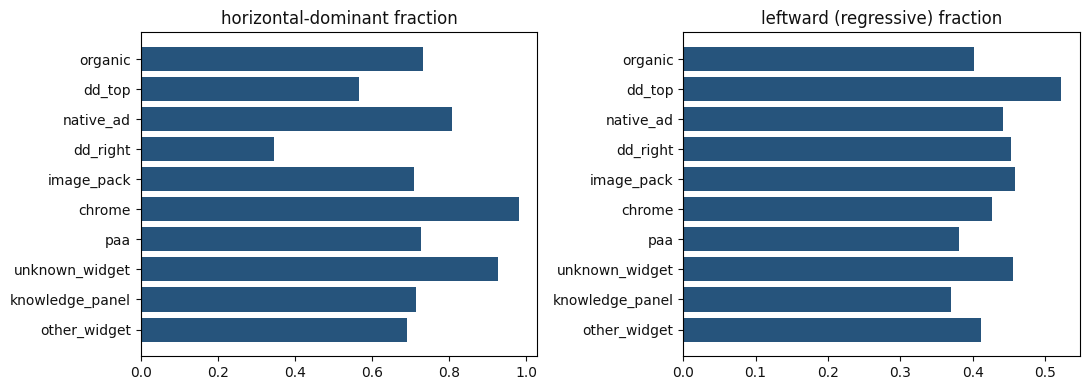

In [4]:
# ── Gate A: text vs visual contrast ────────────────────────────────────
# Empirical type split; adjust after seeing the census table above.
TEXT_TYPES = {'organic', 'people_also_ask', 'paa', 'native_ad', 'snippet'}
VISUAL_TYPES = {'dd_top', 'dd_top_cell', 'dd_right', 'carousel', 'image', 'thumbnails', 'shopping'}

labels, horiz, left = [], [], []
for etype, nrec, npairs, hf, nf, nr, lf, ns in rows:
    if npairs < 200:
        continue   # unstable denominators; report drop
    labels.append(etype); horiz.append(hf); left.append(lf)
dropped = [r[0] for r in rows if r[2] < 200]
if dropped:
    print('dropped (<200 pairs):', dropped)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for ax, vals, title in ((axes[0], horiz, 'horizontal-dominant fraction'),
                        (axes[1], left, 'leftward (regressive) fraction')):
    ax.barh(labels, vals, color='#26547c')
    ax.set_title(title, color='#111111')
    ax.tick_params(colors='#111111')
    ax.invert_yaxis()
plt.tight_layout()
plt.savefig('plot_nb33_gateA_type_contrast.png', dpi=150)
plt.show()


organic AOI-instances joined: 11887
Spearman rho(snippet_chars, regressions/visit) = 0.005  (p = 5.79e-01)


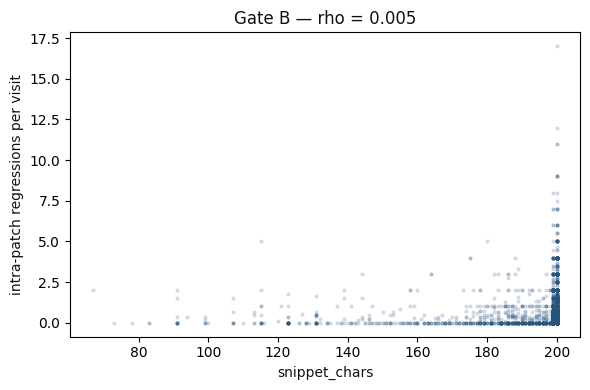

In [5]:
# ── Gate B: regression count vs snippet length (organic only) ─────────
content = json.load(open(CONTENT))
xs, ys = [], []
for r in records:
    if r['type'] != 'organic' or r['pos'] is None:
        continue
    cf = content.get(r['trial'])
    if not cf:
        continue
    match = next((p for p in cf['positions'] if p['pos'] == r['pos']), None)
    if not match or not match.get('snippet_chars'):
        continue
    xs.append(match['snippet_chars'])
    ys.append(r['n_reg'] / max(r['n_visits'], 1))

from scipy.stats import spearmanr
rho, p = spearmanr(xs, ys)
print(f'organic AOI-instances joined: {len(xs)}')
print(f'Spearman rho(snippet_chars, regressions/visit) = {rho:.3f}  (p = {p:.2e})')

fig, ax = plt.subplots(figsize=(6, 4))
ax.scatter(xs, ys, s=4, alpha=0.15, color='#26547c')
ax.set_xlabel('snippet_chars', color='#111111')
ax.set_ylabel('intra-patch regressions per visit', color='#111111')
ax.set_title(f'Gate B — rho = {rho:.3f}', color='#111111')
plt.tight_layout()
plt.savefig('plot_nb33_gateB_snippet_scaling.png', dpi=150)
plt.show()


In [6]:
# ── THETA sensitivity: 20 / 40 / 60 px ─────────────────────────────────
for theta in (20, 40, 60):
    agg = defaultdict(lambda: [0, 0])   # type -> [reg, fwd]
    for tid in trials[::4]:             # quarter sample is plenty for stability
        for r in trial_records(tid, theta=theta):
            agg[r['type']][0] += r['n_reg']
            agg[r['type']][1] += r['n_fwd']
    line = f'theta={theta:>3}: '
    for etype in sorted(agg, key=lambda k: -(agg[k][0] + agg[k][1]))[:5]:
        reg, fwd = agg[etype]
        if reg + fwd:
            line += f"{etype} {reg / (reg + fwd):.1%}  "
    print(line)


theta= 20: organic 40.1%  dd_top 51.7%  native_ad 43.3%  dd_right 47.2%  image_pack 43.5%  
theta= 40: organic 39.8%  dd_top 51.9%  native_ad 43.7%  image_pack 44.4%  dd_right 47.1%  


theta= 60: organic 41.8%  dd_top 52.6%  native_ad 45.7%  image_pack 49.4%  dd_right 44.4%  


In [7]:
# ── First-pass vs re-entry split (two-mechanism preview) ───────────────
from scipy.stats import wilcoxon
pp = defaultdict(lambda: {'fp_reg': 0, 'fp_fwd': 0, 're_reg': 0, 're_fwd': 0})
for r in records:
    if r['type'] != 'organic':
        continue
    for k in pp[r['participant']]:
        pp[r['participant']][k] += r[k]

fp_rates, re_rates = [], []
for p_, v in pp.items():
    if v['fp_reg'] + v['fp_fwd'] >= 20 and v['re_reg'] + v['re_fwd'] >= 20:
        fp_rates.append(v['fp_reg'] / (v['fp_reg'] + v['fp_fwd']))
        re_rates.append(v['re_reg'] / (v['re_reg'] + v['re_fwd']))

stat, pval = wilcoxon(fp_rates, re_rates)
print(f'participants with >=20 horiz saccades in both phases: {len(fp_rates)}')
print(f'first-pass leftward rate: mean {np.mean(fp_rates):.1%}')
print(f're-entry  leftward rate: mean {np.mean(re_rates):.1%}')
print(f'Wilcoxon signed-rank: W = {stat:.0f}, p = {pval:.2e}')


participants with >=20 horiz saccades in both phases: 47
first-pass leftward rate: mean 42.3%
re-entry  leftward rate: mean 39.4%
Wilcoxon signed-rank: W = 235, p = 3.26e-04


In [8]:
# ── Key Claims candidates (transcribe to markdown after verification) ──
total_pairs = sum(t['n_pairs'] for t in by_type.values())
org = by_type.get('organic', {})
org_lf = org.get('n_reg', 0) / max(org.get('n_fwd', 0) + org.get('n_reg', 0), 1)
print('| ID | Claim | Value |')
print('|---|---|---|')
print(f"| K1 | Trials in census (fixation ∩ typed_gapfill) | {len(trials)} |")
print(f"| K2 | Within-AOI saccade pairs, corpus-wide | {total_pairs:,} |")
print(f"| K3 | Organic leftward fraction (theta=40) | {org_lf:.1%} |")
print(f"| K4 | Gate B Spearman rho (snippet_chars x reg/visit) | {rho:.3f} (p={p:.1e}) |")
print(f"| K5 | First-pass vs re-entry leftward rate (organic) | {np.mean(fp_rates):.1%} vs {np.mean(re_rates):.1%} (Wilcoxon p={pval:.1e}) |")


| ID | Claim | Value |
|---|---|---|
| K1 | Trials in census (fixation ∩ typed_gapfill) | 2776 |
| K2 | Within-AOI saccade pairs, corpus-wide | 126,514.0 |
| K3 | Organic leftward fraction (theta=40) | 40.2% |
| K4 | Gate B Spearman rho (snippet_chars x reg/visit) | 0.005 (p=5.8e-01) |
| K5 | First-pass vs re-entry leftward rate (organic) | 42.3% vs 39.4% (Wilcoxon p=3.3e-04) |


### Caveats

- **No line assignment.** 150 Hz Gazepoint at ~20–40 px accuracy vs ~20 px SERP
  line-height: direction statistics only. "Regression to previous line" and
  "re-fixation within line" are indistinguishable here and are not claimed.
- **Return-sweep heuristic** (dx ≤ −0.5·width ∧ dy > 0) is amplitude-based, not
  line-based; sweeps landing with noisy dy will leak into the regression count.
  The THETA sensitivity cell bounds how much classification is threshold-fragile.
- **Forced-click task constraint** (see NB07a): re-evaluation is incentivized;
  intra-patch rates are an upper bound for free browsing.
- **`[LAB]`-only.** No cursor analog exists for x-axis reading direction; this
  measure cannot earn `[BOTH]` and any WILD transfer claim is off the table.
- Regression amplitude distributions (`reg_amp`, `fwd_amp` fields) are collected
  but not analyzed here — reserved for the LHIPA coupling test (planned NB34).
